# Mini-Project 1: Advanced Python Data Exploration & Automated Reporting
**Author:** Student  
**Dataset:** Sample - Superstore 2019.xls  
**Tooling:** Python (Pandas, NumPy, Matplotlib, Seaborn)

---

## Executive Summary
This notebook documents an end-to-end automated data pipeline developed using Object-Oriented Programming (OOP) concepts in Python. It loads sales data, performs data cleaning, builds engineered features, generates exploratory visualizations, and exports automated KPI summaries.

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
plt.style.use('ggplot')
%matplotlib inline

## 1. Class Architecture Definition (OOP Setup)
Defining the `SuperstoreAnalyzer` class responsible for encapsulating data loading, preprocessing, feature engineering, and reporting modules.

## 1. Class Architecture Definition (OOP Setup)
Defining the `SuperstoreAnalyzer` class responsible for encapsulating data loading, preprocessing, feature engineering, and reporting modules.

In [17]:
class SuperstoreAnalyzer:
    
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None
        self.df_cleaned = None
        self.output_folder = "superstore_output_report"
        
        if not os.path.exists(self.output_folder):
            os.makedirs(self.output_folder)

    def load_and_inspect(self):
        print("--- Step 1: Loading & Inspecting Data ---")
        try:
            if self.file_path.endswith('.xls') or self.file_path.endswith('.xlsx'):
                try:
                    self.df = pd.read_excel(self.file_path)
                except Exception:
                    self.df = pd.read_excel(self.file_path, engine='xlrd')
            else:
                self.df = pd.read_csv(self.file_path, encoding='latin1')
            
            print(f"Dataset Loaded Successfully! Shape: {self.df.shape}")
            print("\nMissing Values Count:")
            print(self.df.isnull().sum())
        except Exception as e:
            print(f"Error loading file: {e}")

    def clean_data(self):
        print("\n--- Step 2: Cleaning Data & Optimizing Memory ---")
        df = self.df.copy()

        df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')
        df = df.drop_duplicates()

        if 'order_date' in df.columns:
            df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
        if 'ship_date' in df.columns:
            df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce')

        num_cols = df.select_dtypes(include=[np.number]).columns
        df[num_cols] = df[num_cols].fillna(df[num_cols].median())

        for col in ['sales', 'profit']:
            if col in df.columns:
                q_low = df[col].quantile(0.01)
                q_high = df[col].quantile(0.99)
                df[col] = np.clip(df[col], q_low, q_high)

        for col in df.select_dtypes(include=['object']).columns:
            df[col] = df[col].astype('category')

        self.df_cleaned = df
        print("Data cleaning complete.")

    def add_features(self):
        print("\n--- Step 3: Feature Engineering ---")
        df = self.df_cleaned

        if 'order_date' in df.columns and 'ship_date' in df.columns:
            df['shipping_duration'] = (df['ship_date'] - df['order_date']).dt.days

        if 'sales' in df.columns and 'profit' in df.columns:
            df['profit_margin'] = np.where(df['sales'] > 0, (df['profit'] / df['sales']) * 100, 0)

        if 'order_date' in df.columns:
            df['order_month'] = df['order_date'].dt.strftime('%Y-%m')

        if 'sales' in df.columns:
            q1 = df['sales'].quantile(0.33)
            q2 = df['sales'].quantile(0.66)
            conditions = [
                df['sales'] <= q1,
                (df['sales'] > q1) & (df['sales'] <= q2),
                df['sales'] > q2
            ]
            labels = ['Low', 'Medium', 'High']
            df['sales_performance_category'] = np.select(conditions, labels, default='Medium')

        self.df_cleaned = df

    def generate_visualizations(self):
        print("\n--- Step 4: Generating 8 Visualizations ---")
        df = self.df_cleaned

        # Viz 1: Monthly Sales Trend
        plt.figure(figsize=(8, 4))
        monthly = df.groupby('order_month')['sales'].sum().reset_index()
        sns.lineplot(data=monthly, x='order_month', y='sales', marker='o')
        plt.title('1. Monthly Sales Trend')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(f"{self.output_folder}/1_monthly_sales_trend.png")
        plt.show()

        # Viz 2: Total Sales by Category
        plt.figure(figsize=(7, 4))
        sns.barplot(data=df, x='category', y='sales', estimator=sum, errorbar=None)
        plt.title('2. Total Sales by Category')
        plt.tight_layout()
        plt.savefig(f"{self.output_folder}/2_sales_by_category.png")
        plt.show()

        # Viz 3: Correlation Matrix
        plt.figure(figsize=(6, 4))
        num_df = df.select_dtypes(include=[np.number])
        sns.heatmap(num_df.corr(), annot=True, cmap='Blues', fmt=".2f")
        plt.title('3. Correlation Matrix Heatmap')
        plt.tight_layout()
        plt.savefig(f"{self.output_folder}/3_correlation_heatmap.png")
        plt.show()

        # Viz 4: Sales Value Distribution
        plt.figure(figsize=(7, 4))
        sns.histplot(df['sales'], kde=True, bins=30, color='teal')
        plt.title('4. Sales Value Distribution')
        plt.tight_layout()
        plt.savefig(f"{self.output_folder}/4_sales_distribution.png")
        plt.show()

        # Viz 5: Shipping Duration Boxplot
        plt.figure(figsize=(7, 4))
        if 'ship_mode' in df.columns and 'shipping_duration' in df.columns:
            sns.boxplot(data=df, x='ship_mode', y='shipping_duration')
            plt.title('5. Shipping Duration across Ship Modes')
            plt.tight_layout()
            plt.savefig(f"{self.output_folder}/5_shipping_duration_boxplot.png")
            plt.show()

        # Viz 6: Regional Profit Contribution
        plt.figure(figsize=(7, 4))
        if 'region' in df.columns:
            sns.barplot(data=df, x='region', y='profit', estimator=sum, errorbar=None)
            plt.title('6. Total Profit by Region')
            plt.tight_layout()
            plt.savefig(f"{self.output_folder}/6_regional_profit.png")
            plt.show()

        # Viz 7: Discount vs Profitability
        plt.figure(figsize=(7, 4))
        if 'discount' in df.columns:
            sns.scatterplot(data=df, x='discount', y='profit', alpha=0.6)
            plt.title('7. Discount vs Profitability')
            plt.tight_layout()
            plt.savefig(f"{self.output_folder}/7_discount_vs_profit.png")
            plt.show()

        # Viz 8: Sales Performance Categories
        plt.figure(figsize=(6, 4))
        if 'sales_performance_category' in df.columns:
            sns.countplot(data=df, x='sales_performance_category')
            plt.title('8. Orders Count by Sales Performance Category')
            plt.tight_layout()
            plt.savefig(f"{self.output_folder}/8_sales_performance_categories.png")
            plt.show()

    def export_reports(self):
        print("\n--- Step 5: Exporting Automated Reports ---")
        df = self.df_cleaned

        total_sales = df['sales'].sum()
        total_profit = df['profit'].sum()
        avg_margin = df['profit_margin'].mean() if 'profit_margin' in df.columns else 0

        summary_text = f"""
==========================================
        AUTOMATED KPI SUMMARY REPORT
==========================================
Total Revenue (Sales) : ${total_sales:,.2f}
Total Net Profit      : ${total_profit:,.2f}
Average Profit Margin : {avg_margin:.2f}%
Total Records Processed: {len(df)}
==========================================
"""
        print(summary_text)

        with open(f"{self.output_folder}/summary_report.txt", "w", encoding='utf-8') as f:
            f.write(summary_text)

        df.to_csv(f"{self.output_folder}/cleaned_superstore_data.csv", index=False)
        print("Cleaned dataset and executive summary exported successfully.")

## 2. Pipeline Execution & Automated Workflow
Initializing the `SuperstoreAnalyzer` instance and running the complete analytical workflow sequentially.

--- Step 1: Loading & Inspecting Data ---
Dataset Loaded Successfully! Shape: (9994, 21)

Missing Values Count:
Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

--- Step 2: Cleaning Data & Optimizing Memory ---
Data cleaning complete.

--- Step 3: Feature Engineering ---

--- Step 4: Generating 8 Visualizations ---


C:\Users\GIGABYTE2024\AppData\Local\Temp\ipykernel_20840\1883819640.py:50: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


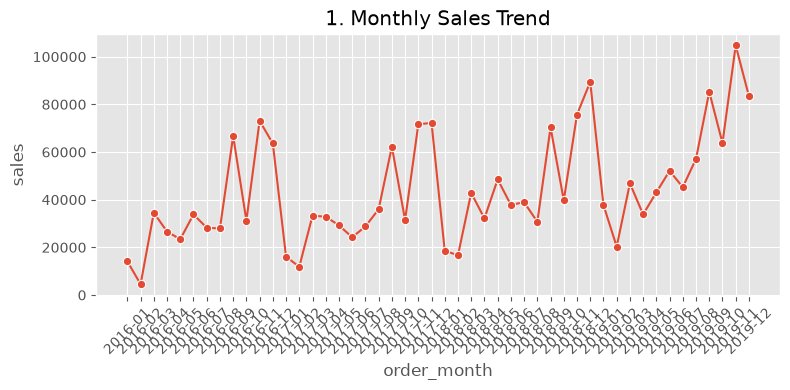

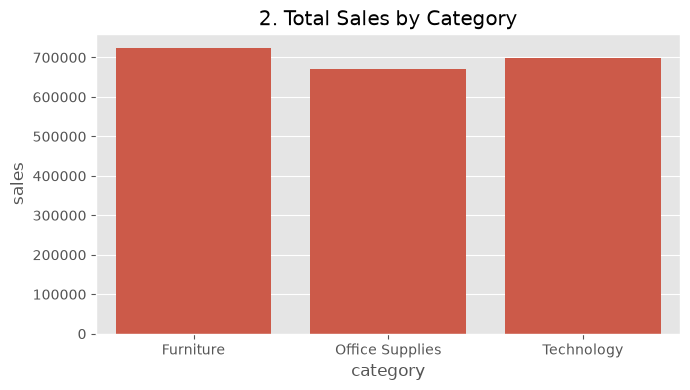

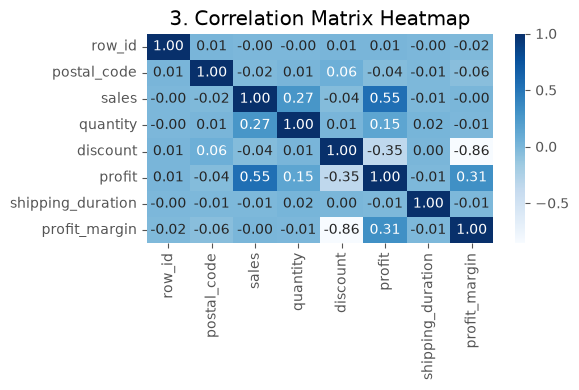

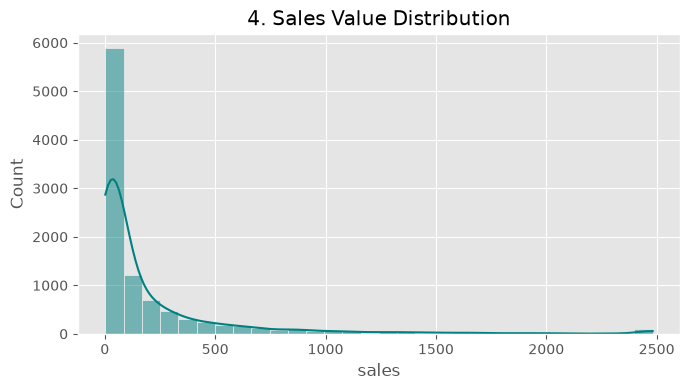

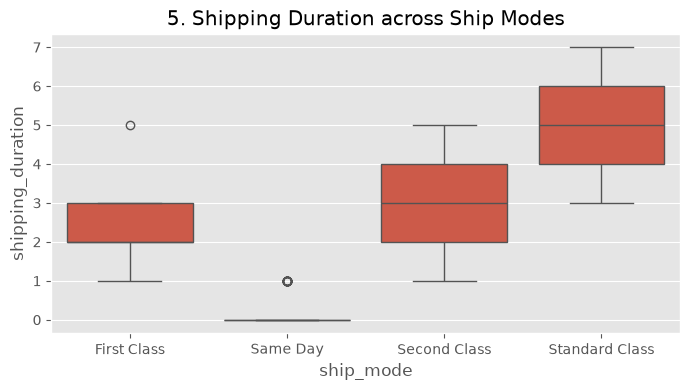

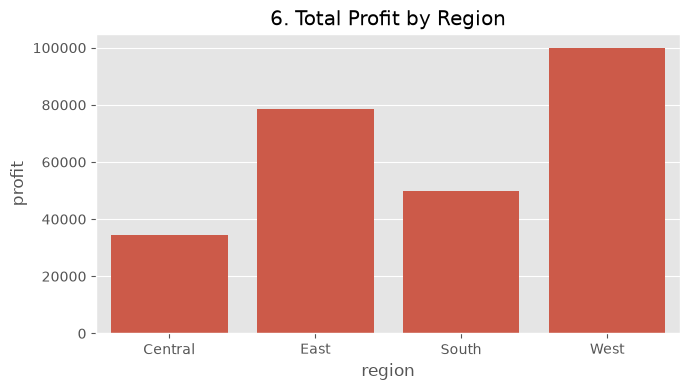

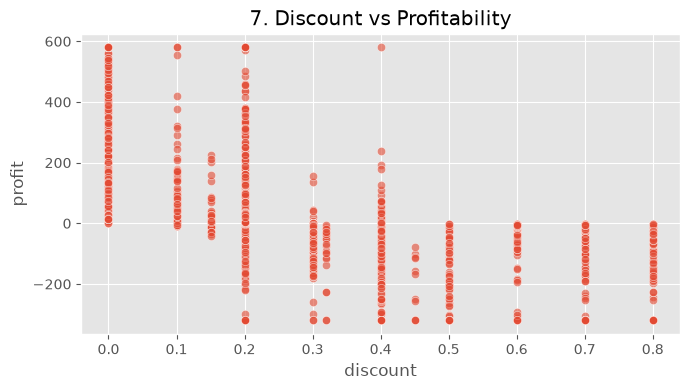

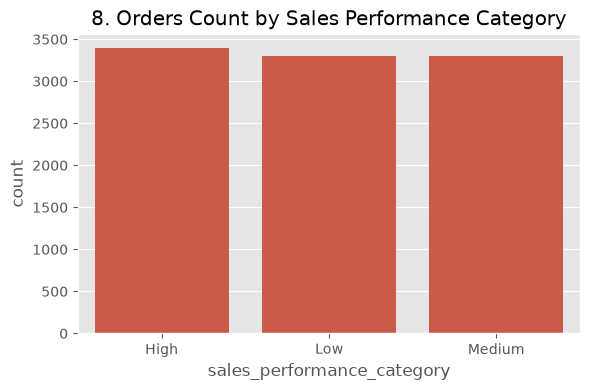


--- Step 5: Exporting Automated Reports ---

        AUTOMATED KPI SUMMARY REPORT
Total Revenue (Sales) : $2,092,398.89
Total Net Profit      : $262,912.48
Average Profit Margin : 12.62%
Total Records Processed: 9994

Cleaned dataset and executive summary exported successfully.


In [18]:
# Instantiate and run the pipeline
file_name = "I:/Python_Learning/Sample - Superstore 2019.xls"

app = SuperstoreAnalyzer(file_name)
app.load_and_inspect()
app.clean_data()
app.add_features()
app.generate_visualizations()
app.export_reports()